In [2]:
 #Step 1: Import Required Libraries
 import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
!pip -q install scikit-image

import math, glob
from pathlib import Path

from skimage.filters import threshold_otsu
from skimage.morphology import skeletonize, remove_small_objects, square, opening, closing
from skimage.segmentation import clear_border
from scipy.ndimage import distance_transform_edt, binary_fill_holes



In [3]:
#Step 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
#Step 3: Define Dataset Paths
base_path = Path("/content/drive/My Drive/Colab Notebooks/Project")
train_dir = base_path / "train"
vali_dir = base_path / "validation"
test_dir = base_path / "test"


In [5]:
#Step 4: Create DataFrame from Folder Structure
data = []
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for fname in os.listdir(class_path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                data.append({'filepath': os.path.join(class_path, fname), 'Label': class_name})

all_df = pd.DataFrame(data)


In [6]:
#Step 5: Split into Training and Testing Sets
train_df, test_df = train_test_split(
    all_df,
    train_size=0.8,
    stratify=all_df['Label'],
    random_state=42,
    shuffle=True
)


In [7]:
# Step 6: Define Image Data Generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_gen = ImageDataGenerator(rescale=1./255)


In [8]:
#Step 7: Generate Data from DataFrame
img_size = (64, 64)
batch_size = 32

train_data = train_gen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='Label',
    target_size=img_size,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    subset='training'
)

val_data = train_gen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='Label',
    target_size=img_size,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    subset='validation'
)

test_data = test_gen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='Label',
    target_size=img_size,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)


Found 3085 validated image filenames belonging to 7 classes.
Found 771 validated image filenames belonging to 7 classes.
Found 964 validated image filenames belonging to 7 classes.


In [9]:
#Step 8: Define the CNN Model
class_names = list(train_data.class_indices.keys())
num_classes = len(class_names)

inputs = tf.keras.Input(shape=(64, 64, 3))
x = Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001))(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)


In [10]:
#Step 9: Compile and Save the Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.save("my_model.keras")


In [11]:
#Step 10: Define Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
]


In [12]:
#Step 11: Train the Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 1079s 11s/step - accuracy: 0.4990 - loss: 1.3857 - val_accuracy: 0.1362 - val_loss: 4.5319 - learning_rate: 0.0010
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 19s 201ms/step - accuracy: 0.6634 - loss: 0.9459 - val_accuracy: 0.1362 - val_loss: 5.8945 - learning_rate: 0.0010
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 19s 197ms/step - accuracy: 0.6976 - loss: 0.8409 - val_accuracy: 0.1362 - val_loss: 6.1718 - learning_rate: 0.0010
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7197 - loss: 0.7945
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
97/97 ━━━━━━━━━━━━━━━━━━━━ 20s 203ms/step - accuracy: 0.7197 - loss: 0.7946 - val_accuracy: 0.1362 - val_loss: 5.0848 - learning_rate: 0.0010
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 19s 196ms/step - accuracy: 0.7104 - loss: 0.7605 - val_accuracy: 0.2815 - val_loss: 2.4763 - learning_rate: 5.0000e-04
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 20s 211ms/step - accuracy: 0.7413 - loss: 

In [13]:
# Step 14: Evaluate the Model
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


31/31 ━━━━━━━━━━━━━━━━━━━━ 259s 9s/step - accuracy: 0.7491 - loss: 0.7402
Test Loss: 0.6794
Test Accuracy: 77.28%


31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step


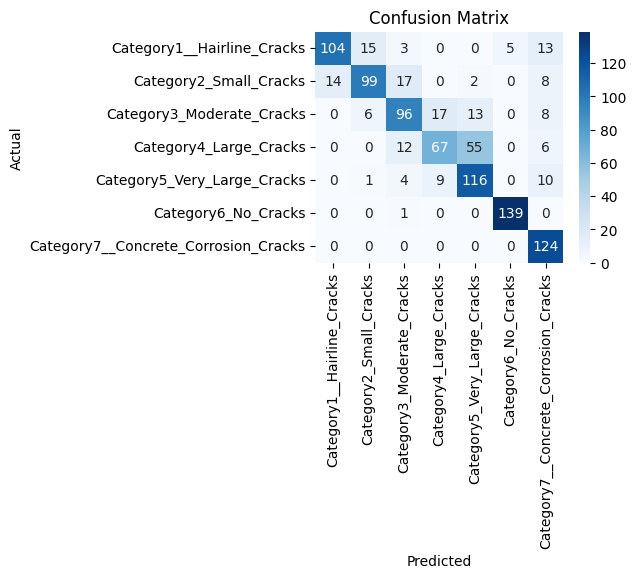

In [14]:
#Step 13: Generate Confusion Matrix
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = test_data.classes

conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("Confusion_matrix.png", dpi=300)
plt.show()


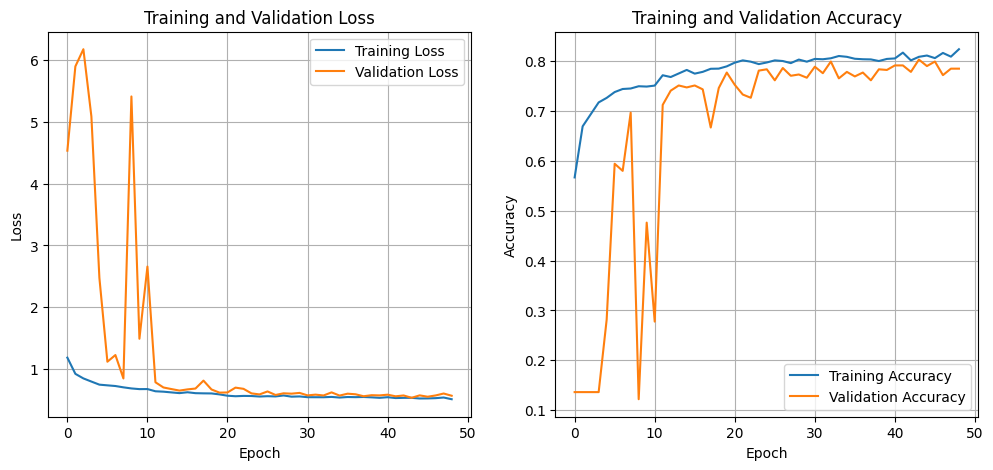

In [15]:
# Plot training history
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig("training_validation_loss.png")

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("training_validation_accuracy.png")

plt.show()


In [ ]:
#Step 15: Classification Report
print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


Classification Report:
                                      precision    recall  f1-score   support

          Category1__Hairline_Cracks       0.88      0.83      0.85       140
              Category2_Small_Cracks       0.81      0.77      0.79       140
           Category3_Moderate_Cracks       0.74      0.68      0.71       140
              Category4_Large_Cracks       0.72      0.54      0.61       140
         Category5_Very_Large_Cracks       0.67      0.84      0.75       140
                 Category6_No_Cracks       0.97      1.00      0.99       140
Category7__Concrete_Corrosion_Cracks       0.84      1.00      0.91       124

                            accuracy                           0.80       964
                           macro avg       0.80      0.81      0.80       964
                        weighted avg       0.80      0.80      0.80       964



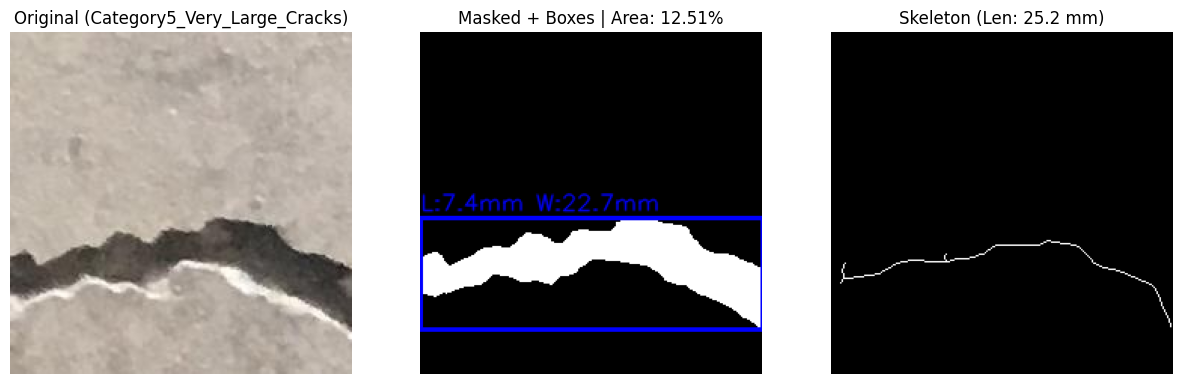

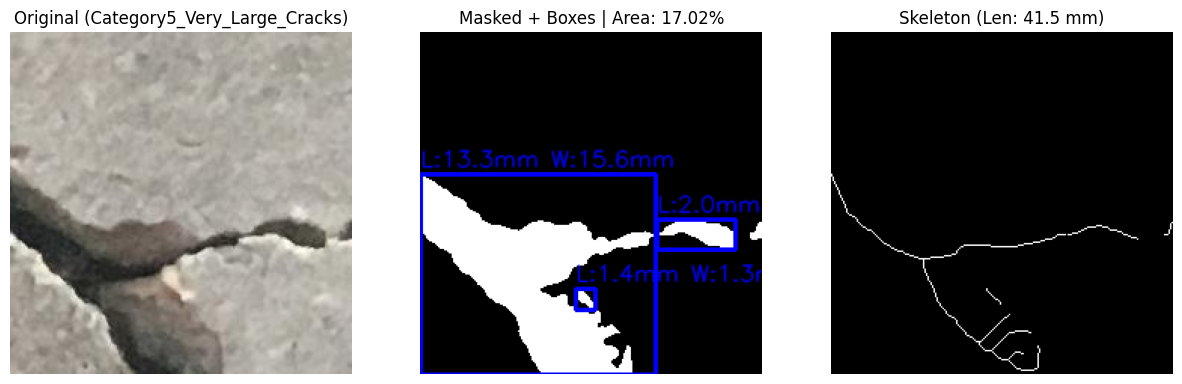

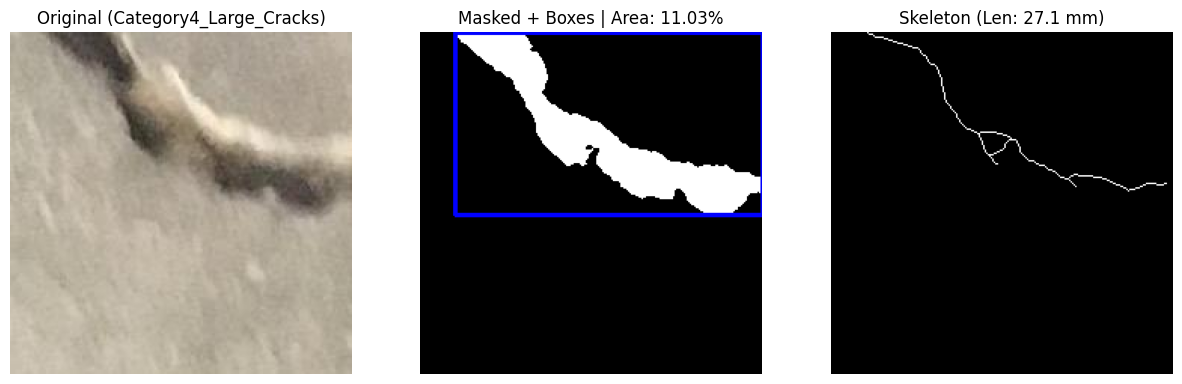

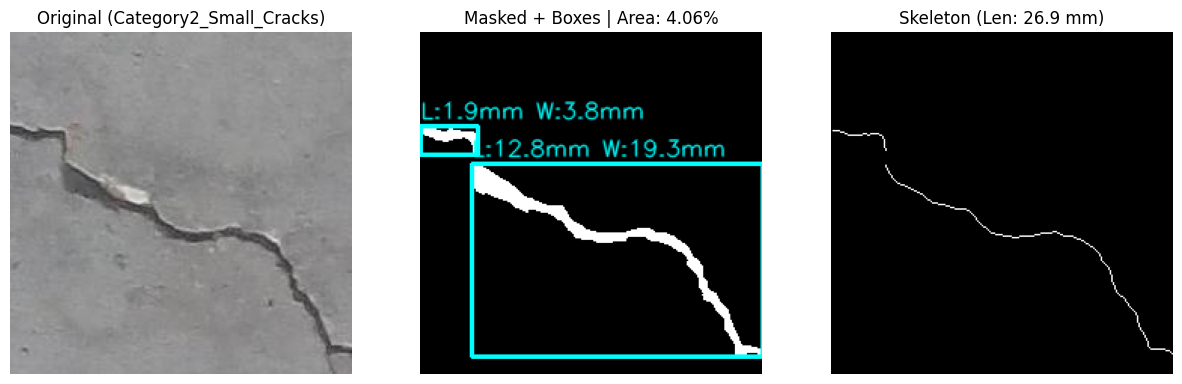

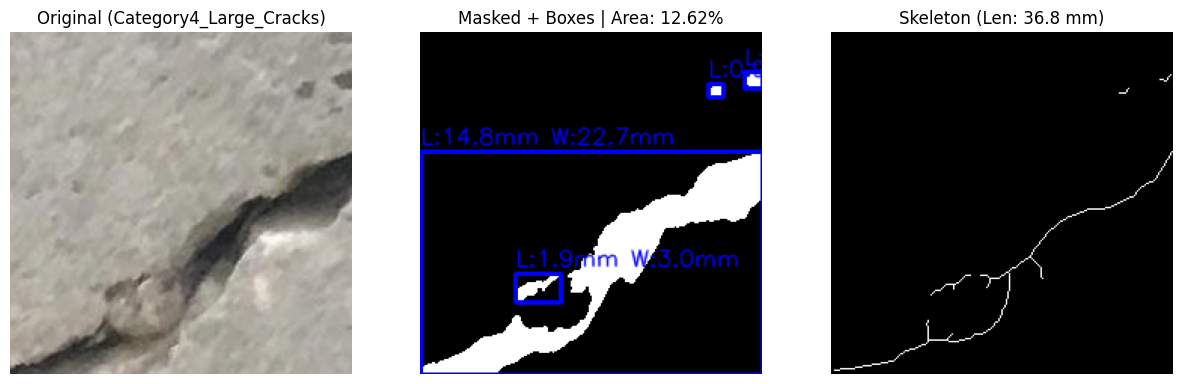

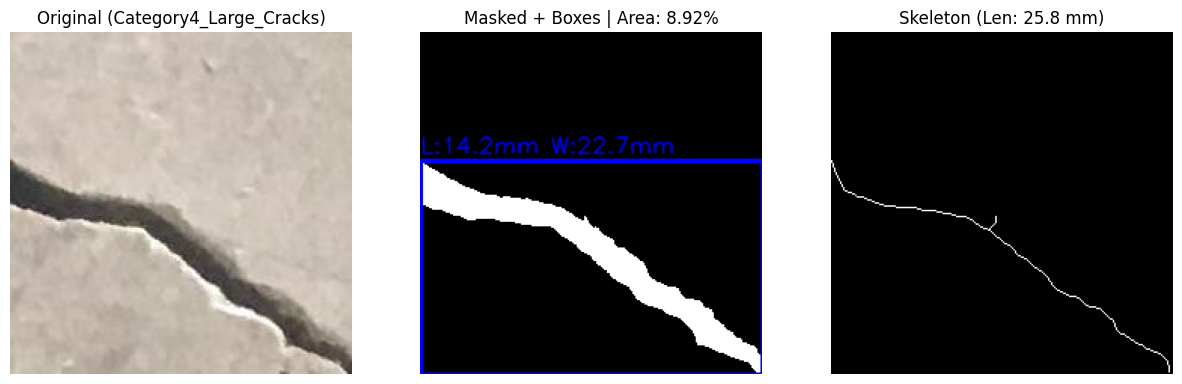

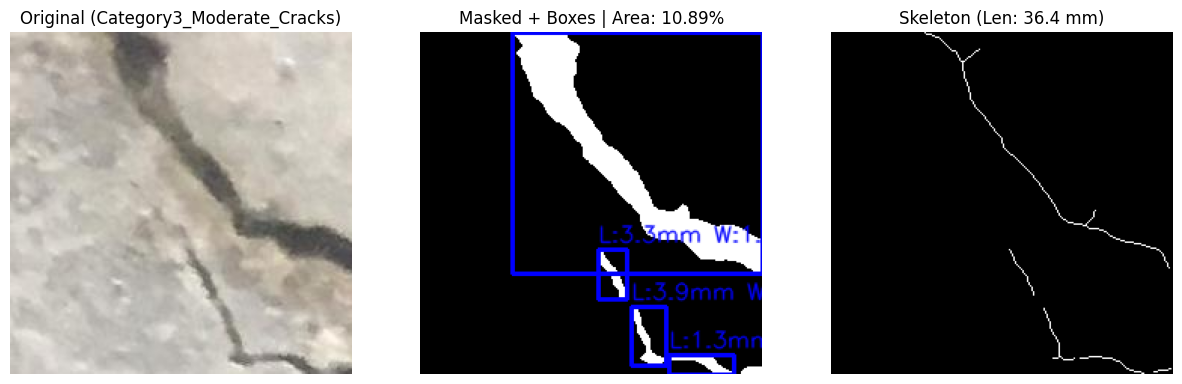

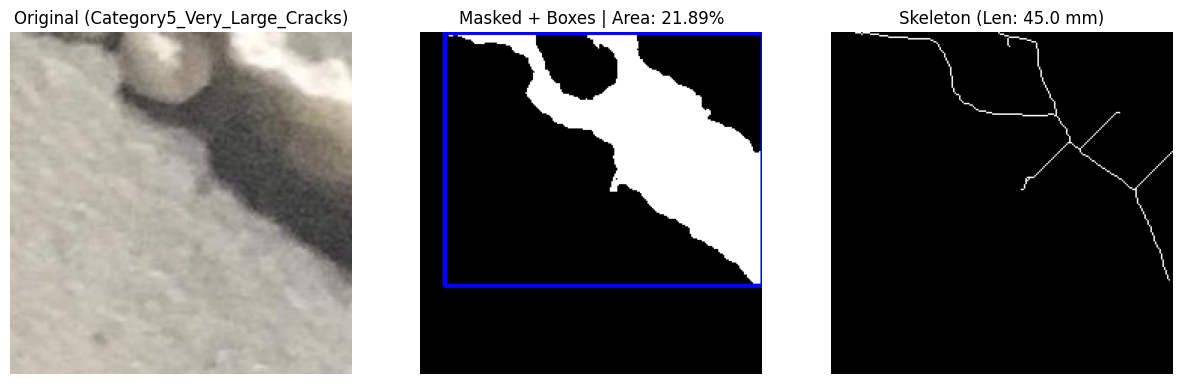

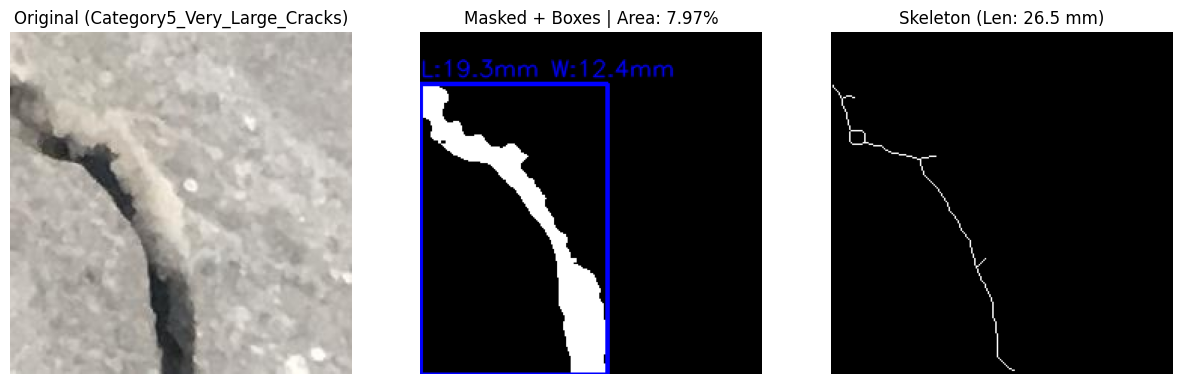

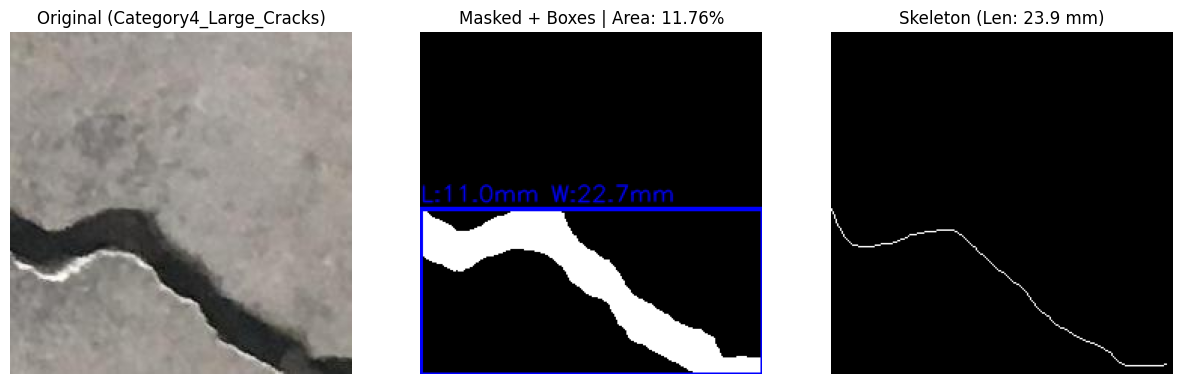


===== Crack Measurement Results (Improved) =====

      Image                       Class  Num_Cracks                     Lengths_mm                      Widths_mm  Skeleton_Length_mm  Affected_Percentage
  07386.jpg Category5_Very_Large_Cracks           1                        [26.43]                          [5.3]                25.2                12.51
  08734.jpg Category5_Very_Large_Cracks           4      [17.42, 5.19, 1.33, 1.77]       [8.74, 1.54, 0.69, 0.61]                41.5                17.02
  03170.jpg      Category4_Large_Cracks           1                        [24.74]                         [5.16]                27.1                11.03
  03558.jpg      Category2_Small_Cracks           2                   [4.57, 27.1]                   [1.09, 4.13]                26.9                 4.06
  04184.jpg      Category4_Large_Cracks           4      [1.28, 1.11, 29.03, 3.48]       [1.07, 0.82, 4.25, 0.86]                36.8                12.62
  01908.jpg      Ca

In [28]:
from skimage.morphology import skeletonize

def skeleton_crack_length(mask, pixel_to_mm=0.1):
    """Compute crack length using skeletonization."""
    binary = (mask > 0).astype(np.uint8)
    skeleton = skeletonize(binary).astype(np.uint8)
    length_px = np.sum(skeleton)  # count skeleton pixels
    return round(length_px * pixel_to_mm, 2), skeleton

def analyze_cracks_only(test_df, pixel_to_mm=0.1, num_images=10):
    # Filter out "No Crack" images
    cracked_df = test_df[~test_df['Label'].str.contains("No", case=False, na=False)]

    # Randomly sample without fixed seed → changes every run
    cracked_sample = cracked_df.sample(min(num_images, len(cracked_df)))

    results = []
    for i, row in cracked_sample.iterrows():
        img_path = row['filepath']
        original_img, _ = preprocess_image(img_path)

        mask = crack_mask_from_edges(original_img)
        dimensions = measure_crack_dimensions(mask, pixel_to_mm)
        percentage = crack_area_percentage(mask)

        # Skeletonize for true crack length
        crack_length, skeleton = skeleton_crack_length(mask, pixel_to_mm)

        lengths = [d[0] for d in dimensions]
        widths  = [d[1] for d in dimensions]

        results.append({
            "Image": os.path.basename(img_path),
            "Class": row['Label'],
            "Num_Cracks": len(dimensions),
            "Lengths_mm": lengths,
            "Widths_mm": widths,
            "Skeleton_Length_mm": crack_length,
            "Affected_Percentage": round(percentage, 2)
        })

        # ===== Visualization with bounding boxes =====
        mask_bgr = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            if cv2.contourArea(cnt) < 50:
                continue
            x, y, w, h = cv2.boundingRect(cnt)
            crack_length_mm = round(h * pixel_to_mm, 2)
            crack_width_mm  = round(w * pixel_to_mm, 2)

            # Color by severity
            color = (0,255,0) if percentage < 2 else (0,255,255) if percentage < 5 else (0,0,255)

            cv2.rectangle(mask_bgr, (x,y), (x+w, y+h), color, 2)
            cv2.putText(mask_bgr, f"L:{crack_length_mm}mm W:{crack_width_mm}mm",
                        (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)

        # Plot results
        plt.figure(figsize=(15,5))
        plt.subplot(1,3,1)
        plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Original ({row['Label']})")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(mask_bgr)
        plt.title(f"Masked + Boxes | Area: {percentage:.2f}%")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(skeleton, cmap="gray")
        plt.title(f"Skeleton (Len: {crack_length} mm)")
        plt.axis("off")
        plt.show()

    results_df = pd.DataFrame(results)
    print("\n===== Crack Measurement Results (Improved) =====\n")
    print(results_df.to_string(index=False))
    return results_df

# Run analysis
crack_results = analyze_cracks_only(test_df, pixel_to_mm=0.1, num_images=10)
